In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Process the pdb file and summarize overall results to csv file

In [4]:
#output_dir = "generation-results/dplm_650m"
output_dir = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01"
plddt_dict = {"seq_idx": [], "length": [], "plddt": []}

for pdb_foldername in os.listdir(os.path.join(output_dir, "esmfold_pdb")):
    if not pdb_foldername.startswith("length_"):
        continue
    #length = pdb_foldername.split("_")[3]
    length = pdb_foldername.split("_")[-1]
    for pdb_filename in os.listdir(
        os.path.join(output_dir, f"esmfold_pdb/{pdb_foldername}")
    ):
        seq_idx = pdb_filename.split("_")[1]
        plddt = pdb_filename.split("_")[-1][:-4]
        plddt_dict["seq_idx"].append(int(seq_idx))
        plddt_dict["length"].append(int(length))
        plddt_dict["plddt"].append(float(plddt))

plddt_df = pd.DataFrame(plddt_dict).sort_values("length")
plddt_df = plddt_df.groupby("length", group_keys=False).apply(
    lambda x: x.sort_values("seq_idx")
)
plddt_df.to_csv(os.path.join(output_dir, "result.csv"))
plddt_df

/tmp/ipykernel_626585/1471486429.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plddt_df = plddt_df.groupby("length", group_keys=False).apply(


,seq_idx,length,plddt
length,,,


In [11]:
import os
import pandas as pd

output_dir = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01"
plddt_dict = {"seq_idx": [], "length": [], "plddt": []}

# 400개의 파일이 모여있는 aatype 폴더로 직진!
aatype_dir = os.path.join(output_dir, "esmfold_pdb", "aatype")

for pdb_filename in os.listdir(aatype_dir):
    if not pdb_filename.endswith(".pdb"):
        continue
        
    try:
        # 1. 파일명에서 seq_idx와 plddt 점수 쏙 빼오기
        # 예시: sample_0_plddt_82.0610...pdb
        parts = pdb_filename.split("_")
        seq_idx = int(parts[1])
        plddt = float(parts[3].replace(".pdb", ""))
        
        # 2. PDB 파일을 열어서 실제 단백질 길이(아미노산 개수) 직접 세기!
        pdb_path = os.path.join(aatype_dir, pdb_filename)
        length = 0
        with open(pdb_path, 'r') as f:
            for line in f:
                # 3D 구조 데이터에서 '알파 탄소(CA)'의 개수 = 아미노산 서열 길이
                if line.startswith("ATOM") and line[12:16].strip() == "CA":
                    length += 1
                    
        # 3. 표에 데이터 추가
        plddt_dict["seq_idx"].append(seq_idx)
        plddt_dict["length"].append(length)
        plddt_dict["plddt"].append(plddt)
        
    except Exception as e:
        continue  # 만약 에러가 나면 조용히 패스

# 표(DataFrame) 만들기
plddt_df = pd.DataFrame(plddt_dict)

if not plddt_df.empty:
    # 길이(100, 200..) 순서대로, 그리고 번호 순서대로 예쁘게 정렬
    plddt_df = plddt_df.sort_values(["length", "seq_idx"])

plddt_df.to_csv(os.path.join(output_dir, "result.csv"), index=False)
plddt_df

,seq_idx,length,plddt
0,0,100,82.061028
1,1,100,84.854179
2,2,100,86.236267
3,3,100,75.019493
4,4,100,62.750328
...,...,...,...
395,95,400,84.533340
396,96,400,76.031464
397,97,400,75.020866
398,98,400,83.706345


In [9]:
import os

output_dir = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01"
esmfold_dir = os.path.join(output_dir, "esmfold_pdb")

print("=== esmfold_pdb 폴더 안의 실제 내용물 목록 ===")
items = os.listdir(esmfold_dir)
for name in items[:20]:  # 너무 많을 수 있으니 상위 20개만 출력
    path = os.path.join(esmfold_dir, name)
    type_str = "폴더" if os.path.isdir(path) else "파일"
    print(f"[{type_str}] {name}")

print(f"\n총 개수: {len(items)}개")

=== esmfold_pdb 폴더 안의 실제 내용물 목록 ===
[폴더] struct_token
[폴더] aatype

총 개수: 2개


In [10]:
import os

output_dir = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01"
esmfold_dir = os.path.join(output_dir, "esmfold_pdb")

for sub_folder in ["struct_token", "aatype"]:
    path = os.path.join(esmfold_dir, sub_folder)
    if os.path.exists(path) and os.path.isdir(path):
        print(f"\n=== {sub_folder} 폴더 안의 내용물 목록 (상위 5개) ===")
        files = os.listdir(path)
        for f in files[:5]:
            print(f)
        print(f"총 개수: {len(files)}개")


=== struct_token 폴더 안의 내용물 목록 (상위 5개) ===
총 개수: 0개

=== aatype 폴더 안의 내용물 목록 (상위 5개) ===
sample_0_plddt_82.06102752685547.pdb
sample_1_plddt_84.85417938232422.pdb
sample_2_plddt_86.23626708984375.pdb
sample_3_plddt_75.01949310302734.pdb
sample_4_plddt_62.750328063964844.pdb
총 개수: 400개


# Lineplot according to the sequence length

In [12]:
#output_dir_list = ["generation-results/dplm_650m/result.csv"]
output_dir_list = ["/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/result.csv"]
model_name_list = ["dplm_650m"]
plddt_df_list = []
for i, output_dir in enumerate(output_dir_list):
    plddt_df = pd.read_csv(output_dir)
    plddt_df = plddt_df.groupby("length", as_index=False)["plddt"].mean()
    plddt_df["model"] = model_name_list[i]
    plddt_df_list.append(plddt_df)
plddt_df = pd.concat(plddt_df_list, ignore_index=True)
plddt_df

,length,plddt,model
0,100,76.365739,dplm_650m
1,200,84.536599,dplm_650m
2,300,84.562203,dplm_650m
3,400,82.558716,dplm_650m


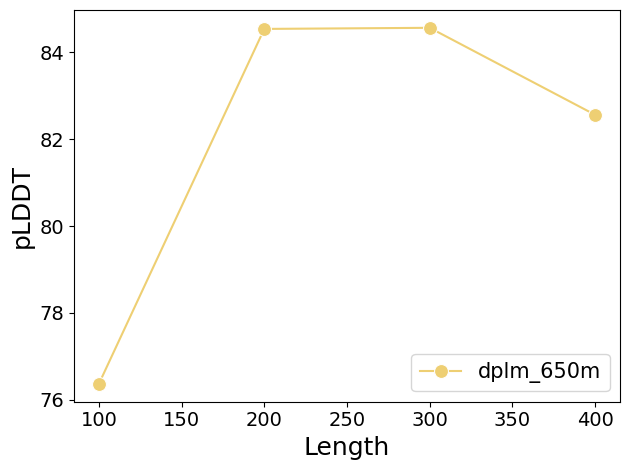

In [13]:
# Create scatter plot
palette_candidate = ["#EECF73", "#5FB1A5", "#F9633D"]
palette = [palette_candidate[i] for i in range(len(model_name_list))]
markers_candidate = ["o", "v", "s"]
markers = [markers_candidate[i] for i in range(len(model_name_list))]
# palette = ['#8dd3c7', '#80b1d3', '#bebada']
sns.lineplot(
    data=plddt_df,
    x="length",
    y="plddt",
    hue="model",
    style="model",
    markers=markers,
    markersize=10,
    dashes=False,
    palette=palette,
)

# Adding labels and title
plt.xlabel("Length", fontdict={"size": 18})
plt.ylabel("pLDDT", fontdict={"size": 18})
plt.xticks(size=14)
plt.yticks(size=14)
plt.tight_layout()
plt.legend(title=None, prop={"size": 15})

# Show plot
plt.show()

# Diversity Analysis

In [14]:
df_length = []


def load_tmscore(eval_dir):
    dfs = []
    for path in glob.glob(eval_dir + "/**/inter_tmscore.csv"):
        print(path)
        df = pd.read_csv(path)
        length = path.split("/")[-2].split("_")[-1]
        df["length"] = [length] * len(df)
        dfs.append(df)
    df_cat = pd.concat(dfs)
    df_cat = df_cat.sort_values("length")
    return df_cat

In [16]:
import pandas as pd
import os
import glob
import numpy as np

def load_tmscore(eval_dir, result_csv_path):
    dfs = []
    # 1. 원본 파일 불러오기
    for path in glob.glob(eval_dir + "/**/inter_tmscore.csv", recursive=True):
        print(f"불러온 파일: {path}")
        df = pd.read_csv(path)
        
        # 2. 쿼리 파일명에서 고유 번호(seq_idx) 쏙 빼오기
        df["seq_idx"] = df["query"].apply(lambda x: int(os.path.basename(x).split("_")[1]))
        dfs.append(df)
        
    df_cat = pd.concat(dfs)
    
    # 3. 아까 완벽하게 만들어둔 plddt 표(result.csv) 불러오기
    plddt_df = pd.read_csv(result_csv_path)
    
    # 4. 고유 번호(seq_idx)를 기준으로 tmscore 표와 길이를 합치기 (퍼즐 맞추기!)
    df_cat = pd.merge(df_cat, plddt_df[["seq_idx", "length"]], on="seq_idx")
    
    # 5. 길이 순서대로 예쁘게 정렬
    df_cat = df_cat.sort_values("length")
    return df_cat

# ==========================================
# 실행 부분 (경로는 질문자님의 환경에 맞게 수정해주세요)
# ==========================================
output_dir = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01"
eval_dir = os.path.join(output_dir, "diversity")
result_csv_path = os.path.join(output_dir, "result.csv")

df_cat = load_tmscore(eval_dir, result_csv_path)

# 데이터가 잘 합쳐졌는지 첫 5줄 미리보기
df_cat.head()

불러온 파일: /mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/diversity/struct_token/inter_tmscore.csv
불러온 파일: /mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/diversity/aatype/inter_tmscore.csv


,Unnamed: 0,query,tm_scores,seq_idx,length
0,0,/mnt/ext-vol/dplm/generation-results/dplm2_650...,"[1.0, 0.31045, 0.3412, 0.26896, 0.22721, 0.349...",0,100
508,127,/mnt/ext-vol/dplm/generation-results/dplm2_650...,"[0.19041, 0.24704, 0.20907, 0.18536, 0.17171, ...",27,100
1076,269,/mnt/ext-vol/dplm/generation-results/dplm2_650...,"[0.1146, 0.18826, 0.13845, 0.15351, 0.13342, 0...",69,100
504,126,/mnt/ext-vol/dplm/generation-results/dplm2_650...,"[0.19012, 0.17707, 0.20763, 0.16337, 0.19995, ...",26,100
1472,368,/mnt/ext-vol/dplm/generation-results/dplm2_650...,"[0.11549, 0.11762, 0.15935, 0.11773, 0.13046, ...",68,100


In [17]:
#dir_path = "../generation-results/dplm_650m/diversity"
dir_path = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/diversity"
df_cat = load_tmscore(dir_path)
df_cat["tm_scores"] = df_cat["tm_scores"].apply(lambda x: eval(x))
df_cat["tm_scores_mean"] = df_cat["tm_scores"].apply(lambda x: sum(x) / len(x))

df = df_cat.groupby("length").apply(lambda x: x["tm_scores_mean"].mean())
df = df.reset_index()
df.columns = ["length", "inner-TM"]
# plt.figure(figsize=(10, 6))
sns.barplot(
    x="length", y="inner-TM", data=df, palette="Spectral", edgecolor="black"
)
plt.xlabel("Length", fontdict={"size": 18})
plt.ylabel("inner-TM", fontdict={"size": 18})
plt.xticks(size=14)
plt.yticks(size=14)
plt.show()

TypeError: load_tmscore() missing 1 required positional argument: 'result_csv_path'

불러온 파일: /mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/diversity/struct_token/inter_tmscore.csv
불러온 파일: /mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/diversity/aatype/inter_tmscore.csv


/tmp/ipykernel_626585/3109030222.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_cat.groupby("length").apply(lambda x: x["tm_scores_mean"].mean())


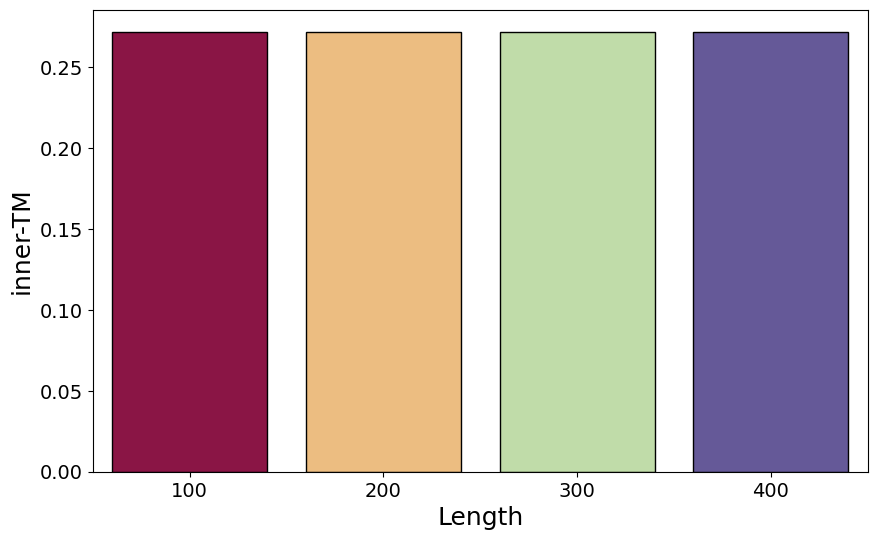

In [18]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 경로 설정 (정답지 경로 추가)
dir_path = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/diversity"
result_csv_path = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/result.csv"

# 2. 우리가 업그레이드한 함수 사용 (인자 2개 전달!)
df_cat = load_tmscore(dir_path, result_csv_path)

# 3. 텍스트로 된 점수 리스트 '[0.8, 0.9...]' 를 파이썬 리스트로 변환
# (기존 eval(x)는 에러가 날 수 있어, 더 안전한 ast.literal_eval을 사용합니다)
def safe_parse(x):
    try:
        return ast.literal_eval(str(x))
    except:
        return []

df_cat["tm_scores"] = df_cat["tm_scores"].apply(safe_parse)
df_cat["tm_scores_mean"] = df_cat["tm_scores"].apply(
    lambda x: sum(x) / len(x) if len(x) > 0 else 0
)

# 4. 길이별로 묶어서 평균의 평균 계산
df = df_cat.groupby("length").apply(lambda x: x["tm_scores_mean"].mean())
df = df.reset_index()
df.columns = ["length", "inner-TM"]

# 5. 멋진 그래프 그리기 (경고문 안 뜨게 hue="length", legend=False 추가)
plt.figure(figsize=(10, 6))
sns.barplot(
    x="length", y="inner-TM", data=df, 
    palette="Spectral", edgecolor="black", 
    hue="length", legend=False
)
plt.xlabel("Length", fontdict={"size": 18})
plt.ylabel("inner-TM", fontdict={"size": 18})
plt.xticks(size=14)
plt.yticks(size=14)
plt.show()

# Novelty Analysis

In [21]:
df_length = []


def load_tmscore(eval_dir):
    dfs = []
    for path in glob.glob(eval_dir + "/**/inter_tmscore.csv"):
        print(path)
        df = pd.read_csv(path)
        length = path.split("/")[-2].split("_")[-1]
        df["length"] = [length] * len(df)
        dfs.append(df)
    df_cat = pd.concat(dfs)
    df_cat = df_cat.sort_values("length")
    return df_cat

../generation-results/dplm_650m/novelty/iter_500_L_100/inter_tmscore.csv
../generation-results/dplm_650m/novelty/iter_500_L_200/inter_tmscore.csv
../generation-results/dplm_650m/novelty/iter_500_L_300/inter_tmscore.csv
../generation-results/dplm_650m/novelty/iter_500_L_400/inter_tmscore.csv
../generation-results/dplm_650m/novelty/iter_500_L_500/inter_tmscore.csv


/tmp/ipykernel_13209/297249591.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_cat.groupby('length').apply(lambda x: x['tm_scores_max'].mean())
/tmp/ipykernel_13209/297249591.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='length', y='pdb-TM', data=df, palette="Spectral", edgecolor="black")


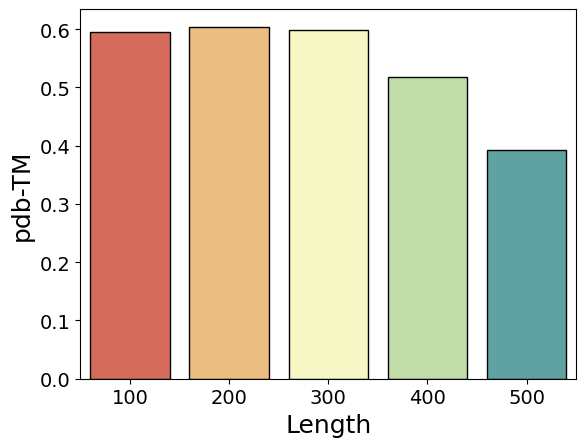

In [ ]:
#dir_path = "../generation-results/dplm_650m/novelty"
dir_path = "/mnt/ext-vol/dplm/generation-results/dplm2_650m_run01/novelty"
df_cat = load_tmscore(dir_path)
df_cat["tm_scores"] = df_cat["tm_scores"].apply(lambda x: eval(x))
df_cat["tm_scores_max"] = df_cat["tm_scores"].apply(lambda x: max(x))

df = df_cat.groupby("length").apply(lambda x: x["tm_scores_max"].mean())
df = df.reset_index()
df.columns = ["length", "pdb-TM"]
# plt.figure(figsize=(10, 6))
sns.barplot(
    x="length", y="pdb-TM", data=df, palette="Spectral", edgecolor="black"
)
plt.xlabel("Length", fontdict={"size": 18})
plt.ylabel("pdb-TM", fontdict={"size": 18})
plt.xticks(size=14)
plt.yticks(size=14)
plt.show()